# **1. Perkenalan Dataset**

Eksperimen ini menggunakan **Credit Risk Dataset** yang bersumber dari public repository **Kaggle** ([Kaggle Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)). Dataset ini menyimpan informasi pengajuan pinjaman nasabah dengan total 32.581 baris dan 12 kolom awal. Fokus utama analisis ini adalah memprediksi kemungkinan nasabah mengalami gagal bayar, yang ditunjukkan oleh kolom target `loan_status` (0 untuk Good Loan/Non-default, dan 1 untuk Default/Gagal Bayar).

Informasi di dalam dataset ini terbagi ke dalam profil pribadi nasabah dan detail pinjaman, antara lain:
- **Profil Pribadi**: Usia (`person_age`), pendapatan tahunan (`person_income`), status kepemilikan rumah (`person_home_ownership`), dan lama bekerja (`person_emp_length`).
- **Detail Kredit**: Tujuan peminjaman (`loan_intent`), kategori kelas kualitas kredit (`loan_grade`), jumlah pinjaman (`loan_amnt`), tingkat suku bunga (`loan_int_rate`), persentase nominal kredit dibanding pendapatan tahunan (`loan_percent_income`), riwayat catatan gagal bayar sebelumnya (`cb_person_default_on_file`), serta durasi riwayat kredit dalam tahun (`cb_person_cred_hist_length`).


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Set style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14
})

# Load dataset
zip_path = 'credit_risk_dataset.csv.zip'
if not os.path.exists(zip_path):
    raise FileNotFoundError(f"File {zip_path} tidak ditemukan di workspace.")

df = pd.read_csv(zip_path)

# Tampilkan shape dataset
print("Shape Dataset:", df.shape)


Shape Dataset: (32581, 12)


In [3]:
# Tampilkan head()
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# Tampilkan info()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
# Tampilkan describe()
df.describe()


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Distribusi Target (loan_status):
- Non-default (0): 25473 baris (78.18%)
- Default (1): 7108 baris (21.82%)


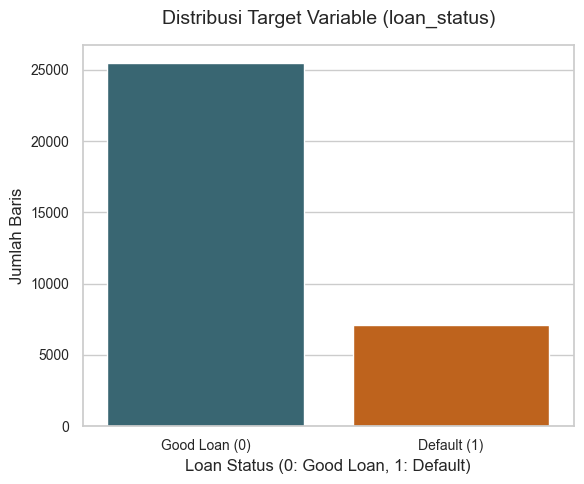

In [6]:
# Cek distribusi target
target_counts = df['loan_status'].value_counts()
target_pct = df['loan_status'].value_counts(normalize=True) * 100

print("Distribusi Target (loan_status):")
for val, count in target_counts.items():
    label = "Non-default (0)" if val == 0 else "Default (1)"
    print(f"- {label}: {count} baris ({target_pct[val]:.2f}%)")

# Visualisasi distribusi target
plt.figure(figsize=(6, 5))
sns.countplot(x='loan_status', hue='loan_status', data=df, palette=['#2F6B7C', '#D95F02'], legend=False)
plt.title('Distribusi Target Variable (loan_status)', fontsize=14, pad=15)
plt.xlabel('Loan Status (0: Good Loan, 1: Default)')
plt.ylabel('Jumlah Baris')
plt.xticks(ticks=[0, 1], labels=['Good Loan (0)', 'Default (1)'])
plt.tight_layout()
plt.show()


In [7]:
# Cek missing values per kolom
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_pct})
print("Missing Values Per Column:")
print(missing_df[missing_df['Missing Count'] > 0])

# Cek duplicate data
duplicate_count = df.duplicated().sum()
print(f"\nJumlah data duplikat: {duplicate_count} baris")


Missing Values Per Column:
                   Missing Count  Percentage (%)
person_emp_length            895        2.747000
loan_int_rate               3116        9.563856

Jumlah data duplikat: 165 baris


In [8]:
# Pisahkan kolom numerik dan kategorikal
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if 'loan_status' in num_cols:
    num_cols.remove('loan_status')

print("Fitur Numerik:", num_cols)
print("Fitur Kategorikal:", cat_cols)

# Ringkasan statistik deskriptif kategorikal
print("\nStatistik Deskriptif Fitur Kategorikal:")
display(df[cat_cols].describe())

# Value counts untuk kolom kategorikal
for col in cat_cols:
    print(f"\nValue Counts untuk kolom '{col}':")
    print(df[col].value_counts())


Fitur Numerik: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Fitur Kategorikal: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Statistik Deskriptif Fitur Kategorikal:


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836



Value Counts untuk kolom 'person_home_ownership':
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

Value Counts untuk kolom 'loan_intent':
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Value Counts untuk kolom 'loan_grade':
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

Value Counts untuk kolom 'cb_person_default_on_file':
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


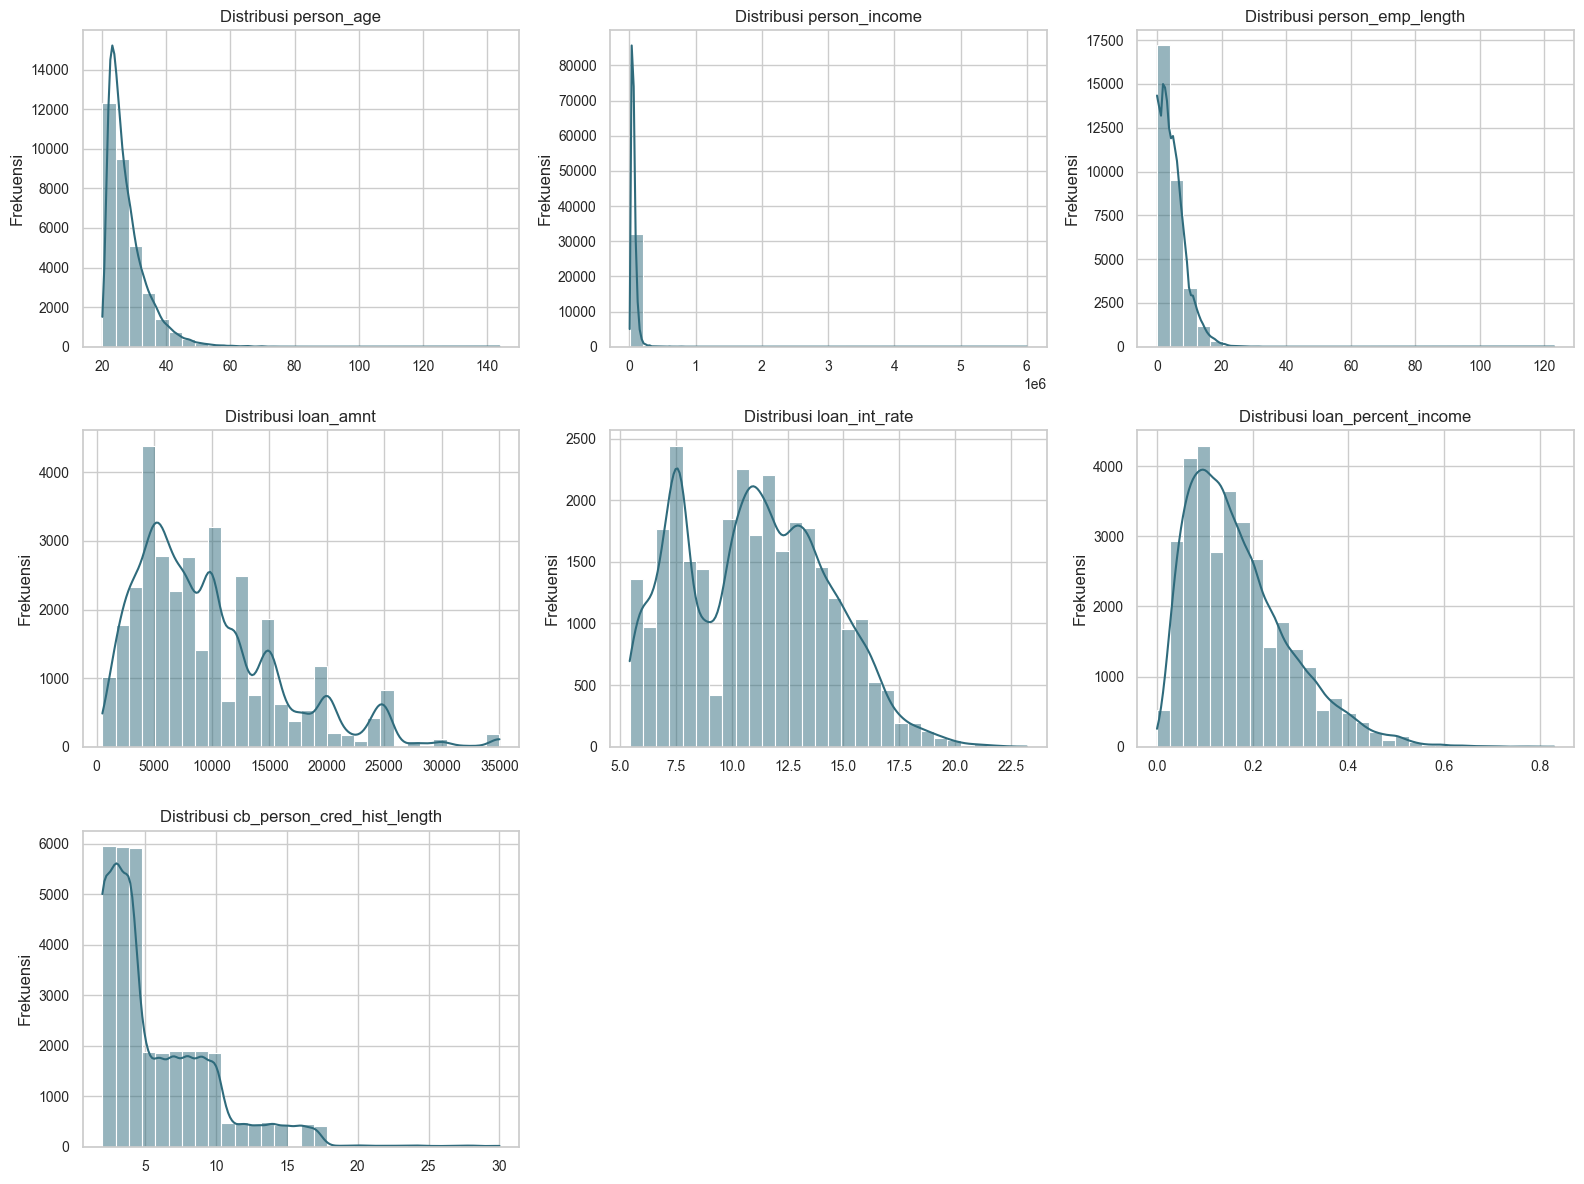

In [9]:
# Visualisasi histogram fitur numerik
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

numeric_features_to_plot = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

for idx, col in enumerate(numeric_features_to_plot):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='#2F6B7C', bins=30)
    axes[idx].set_title(f'Distribusi {col}', fontsize=12)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frekuensi')

# Sembunyikan subplot kosong
for idx in range(len(numeric_features_to_plot), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


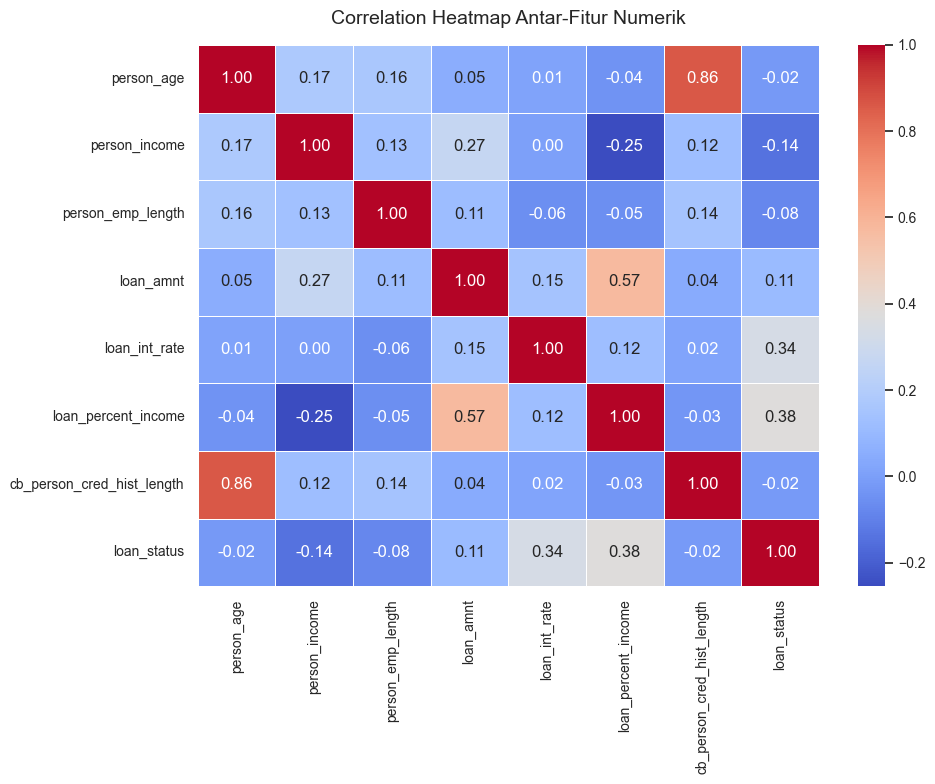

In [10]:
# Heatmap Korelasi
plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols + ['loan_status']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap Antar-Fitur Numerik', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Buat direktori output jika belum ada
output_dir = 'dataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# 3.1 Hapus Duplikasi
print("Shape sebelum drop duplikat:", df.shape)
df_clean = df.drop_duplicates().copy()
print("Shape setelah drop duplikat:", df_clean.shape)

# 3.2 Hapus Outliers Logis (Business Rules Outliers)
# Menghapus person_age > 100 dan person_emp_length > 60
outlier_mask = (df_clean['person_age'] > 100) | (df_clean['person_emp_length'] > 60)
print(f"Jumlah baris outlier logis yang dideteksi & dihapus: {outlier_mask.sum()}")
df_clean = df_clean[~outlier_mask].reset_index(drop=True)
print("Shape setelah pembersihan outlier logis:", df_clean.shape)

# 3.3 Pisahkan Fitur dan Target
X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']

# 3.4 Lakukan Train-Test Split (80/20, Stratified, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

print(f"\nTrain set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Shape sebelum drop duplikat: (32581, 12)
Shape setelah drop duplikat: (32416, 12)
Jumlah baris outlier logis yang dideteksi & dihapus: 7
Shape setelah pembersihan outlier logis: (32409, 12)

Train set shape: (25927, 11)
Test set shape: (6482, 11)


In [12]:
# 3.5 Encode Fitur Kategorikal Spesifik
# Ordinal encoding untuk loan_grade
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
X_train['loan_grade'] = X_train['loan_grade'].map(grade_map)
X_test['loan_grade'] = X_test['loan_grade'].map(grade_map)

# Binary encoding untuk cb_person_default_on_file
default_map = {'N': 0, 'Y': 1}
X_train['cb_person_default_on_file'] = X_train['cb_person_default_on_file'].map(default_map)
X_test['cb_person_default_on_file'] = X_test['cb_person_default_on_file'].map(default_map)

# 3.6 Winsorization (1st/99th percentile) - fit di train set, transform di train & test
win_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
win_bounds = {}

for col in win_cols:
    q_low = X_train[col].quantile(0.01)
    q_high = X_train[col].quantile(0.99)
    win_bounds[col] = (q_low, q_high)
    X_train[col] = X_train[col].clip(q_low, q_high)
    X_test[col] = X_test[col].clip(q_low, q_high)

# 3.7 Imputasi Missing Values (Median Imputation) - fit di train set
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
medians = X_train[numeric_cols].median()

for col in numeric_cols:
    X_train[col] = X_train[col].fillna(medians[col])
    X_test[col] = X_test[col].fillna(medians[col])

# 3.8 Feature Scaling (StandardScaler) - fit di train set
# Catatan: cb_person_default_on_file bersifat biner, tidak ikut diskalakan
scaled_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

# 3.9 One-hot Encoding untuk kolom kategorikal nominal sisa
X_train = pd.get_dummies(X_train, columns=['person_home_ownership', 'loan_intent'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['person_home_ownership', 'loan_intent'], dtype=int)

# Masukkan kembali target
X_train['loan_status'] = y_train
X_test['loan_status'] = y_test

# 3.10 Gabungkan untuk mendapatkan data processed utuh
df_processed = pd.concat([X_train, X_test]).reset_index(drop=True)

# Pastikan urutan kolom di train dan test sama
X_test = X_test[X_train.columns]
df_processed = df_processed[X_train.columns]

print("Final Preprocessed Train Shape:", X_train.shape)
print("Final Preprocessed Test Shape:", X_test.shape)
print("Final Preprocessed Full Shape:", df_processed.shape)


Final Preprocessed Train Shape: (25927, 20)
Final Preprocessed Test Shape: (6482, 20)
Final Preprocessed Full Shape: (32409, 20)
